<a href="https://colab.research.google.com/github/Priya-on-loop/Bharatnatyam_mudras_recognition/blob/main/Exit_Exam_Mudras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import io
import json
import time
import os
import shutil
from pathlib import Path
from collections import Counter

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import (
    MobileNetV2, ResNet50, EfficientNetB0, VGG16, InceptionV3,
    DenseNet121, Xception
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

# Augmentation
import albumentations as A

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


# Load the data

In [3]:
filepath = '/content/drive/MyDrive/AI  and ML/DataSets/Bharatanatyam_Mudras'


In [4]:
img_height = 128
img_width = 128
batch_size = 32

# Load the image dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    filepath,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

# Getting the class name
class_names = dataset.class_names
print(f"Found {len(class_names)} classes: {class_names}")

Found 2000 files belonging to 5 classes.
Found 5 classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']


# EDA

## Sample images

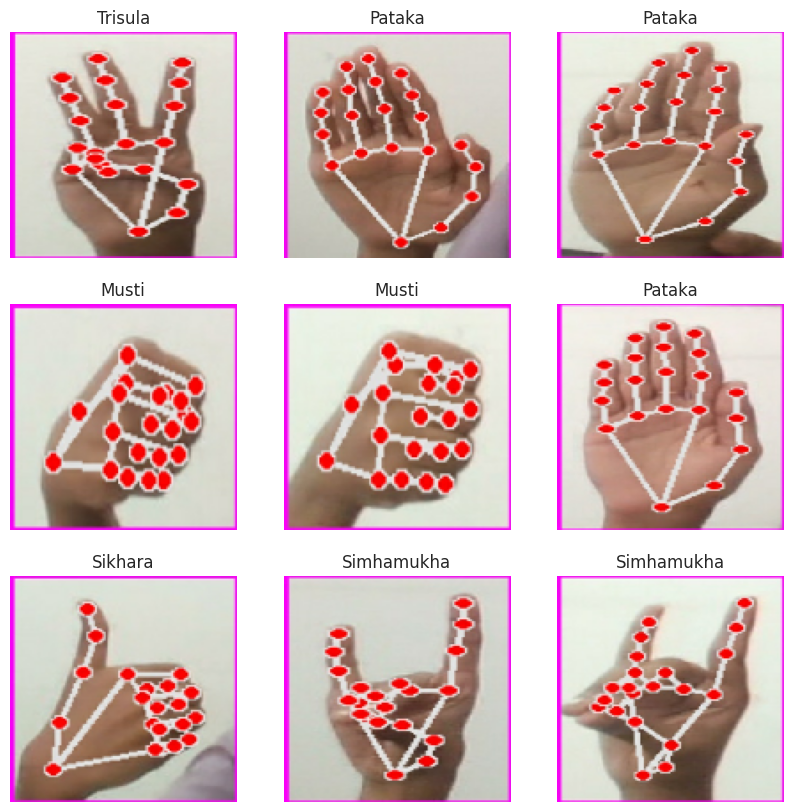

In [5]:
# visualising a few images from the dataset
plt.figure(figsize=(10, 10))
for images, labels in dataset.take(1): # Take one batch
  for i in range(min(9, len(images))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

## Class Distribution

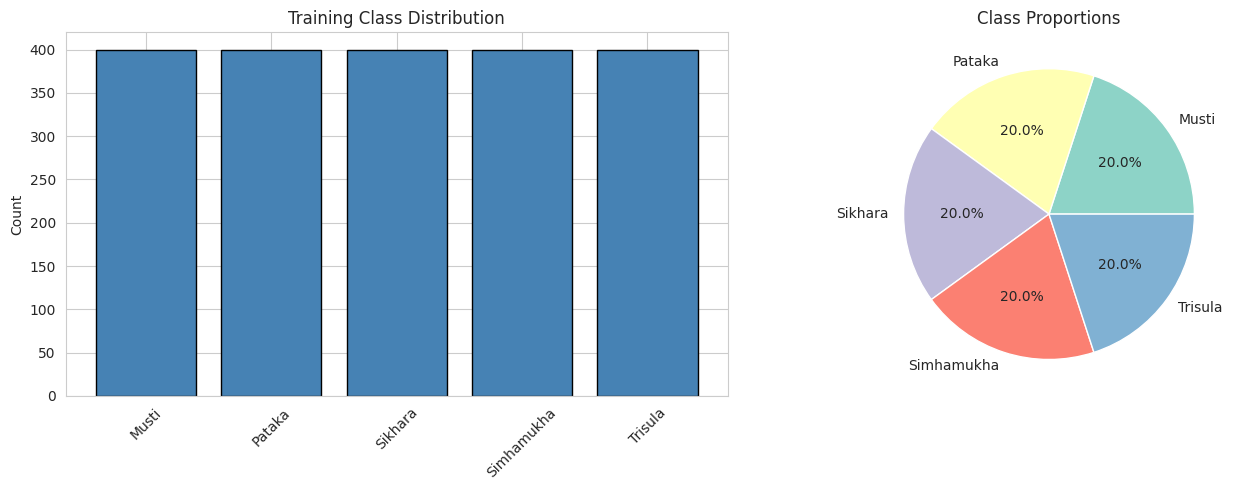

In [6]:
# count the number of class
class_counts = {}
# Iterate through the class names obtained from the dataset
for cls in class_names:
    class_dir_path = os.path.join(filepath, cls)
    if os.path.isdir(class_dir_path):
        class_counts[cls] = len([name for name in os.listdir(class_dir_path) if os.path.isfile(os.path.join(class_dir_path, name))])
    else:
        print(f"Warning: Directory for class '{cls}' not found at {class_dir_path}")

# Checking  if class_counts is empty before plotting
if not class_counts:
    print("No classes found or counted for distribution plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(class_counts.keys(), class_counts.values(),
                color='steelblue', edgecolor='black')
    axes[0].set_title('Training Class Distribution')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].pie(class_counts.values(), labels=class_counts.keys(),
                autopct='%1.1f%%', colors=plt.cm.Set3.colors)
    axes[1].set_title('Class Proportions')

    plt.tight_layout()
    plt.show()

## Image Dimensions and Pixel Value Distribution


***********Image Dimensions****************
All images have uniform dimensions: (128, 128, 3)

****************Pixel Value Distribution***********
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 175.85
Median pixel value: 204.00


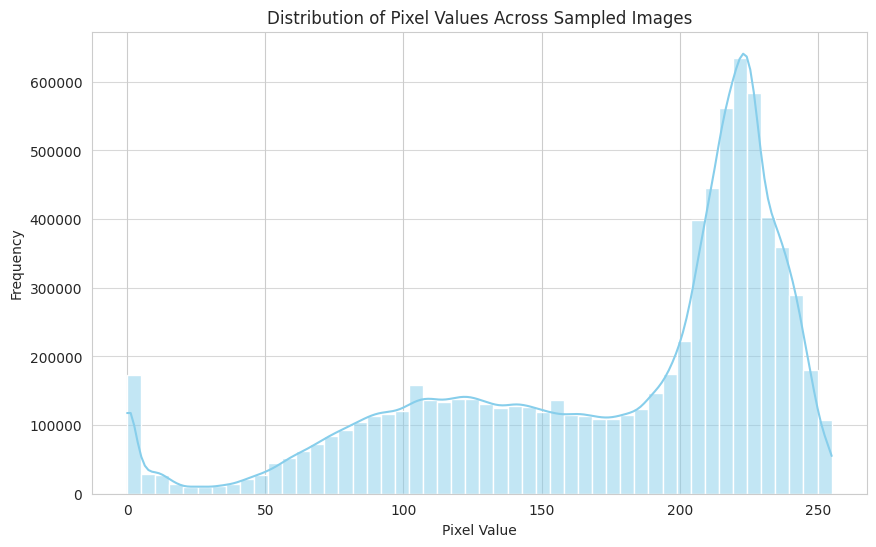

In [7]:
# Collect image dimensions and pixel data from a sample of the dataset
dimensions = []
pixel_values = []

# Iterate through a few batches of the dataset
for images, _ in dataset.take(5):
    for img in images:
        dimensions.append(img.shape)
        pixel_values.extend(img.numpy().flatten())

print("***********Image Dimensions****************")
unique_dimensions = set(dimensions)
if len(unique_dimensions) == 1:
    print(f"All images have uniform dimensions: {list(unique_dimensions)[0]}")
else:
    print(f"Images have varying dimensions. Sample: {list(unique_dimensions)[:5]}...")


# Convert pixel_values to a numpy array for easier manipulation
pixel_values = np.array(pixel_values)

print("\n****************Pixel Value Distribution***********")
print(f"Min pixel value: {pixel_values.min()}")
print(f"Max pixel value: {pixel_values.max()}")
print(f"Mean pixel value: {pixel_values.mean():.2f}")
print(f"Median pixel value: {np.median(pixel_values):.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(pixel_values, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Pixel Values Across Sampled Images')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Image Size Analysis

Mean pixel value: 168.36
Std pixel value: 61.82
Min: 0, Max: 255


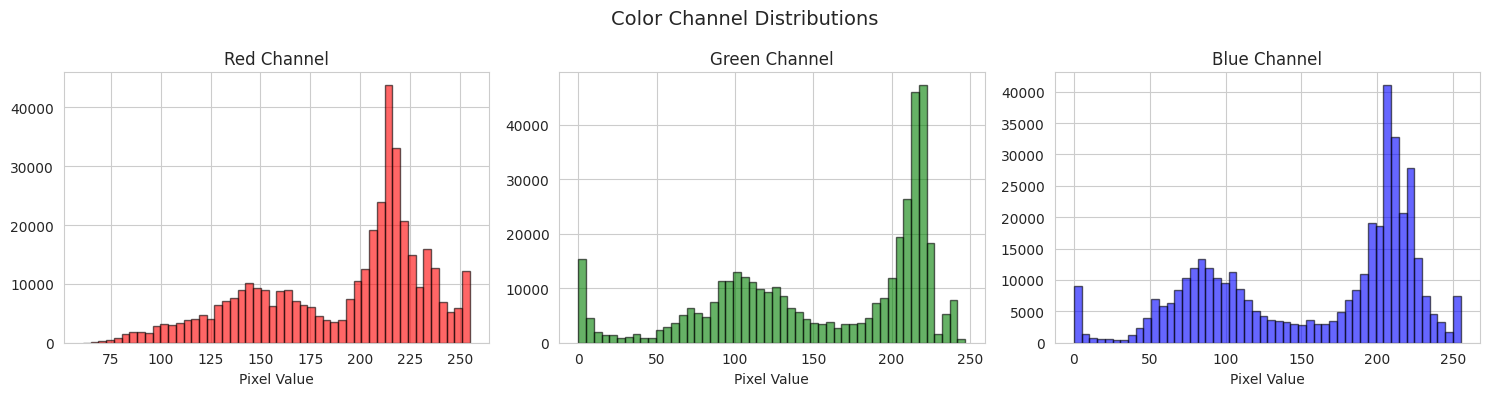

In [8]:
sample_imgs = []
# Iterate through each class name to sample images
for cls_name in class_names:
    class_dir_path = os.path.join(filepath, cls_name)
    if os.path.isdir(class_dir_path):
        # Get up to 5 image files from each class for sampling
        img_files_in_class = [f for f in os.listdir(class_dir_path) if os.path.isfile(os.path.join(class_dir_path, f))]

        for img_filename in img_files_in_class[:5]: # Take first 5 images per class
            full_img_path = os.path.join(class_dir_path, img_filename)
            img = cv2.imread(full_img_path) # Reads image in BGR format
            if img is not None:
                # Resize the image to match the dimensions used in image_dataset_from_directory
                img = cv2.resize(img, (img_width, img_height))
                # Convert BGR to RGB for consistent plotting with matplotlib
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                sample_imgs.append(img)

sample_imgs = np.array(sample_imgs)
print(f"Mean pixel value: {sample_imgs.mean():.2f}")
print(f"Std pixel value: {sample_imgs.std():.2f}")
print(f"Min: {sample_imgs.min()}, Max: {sample_imgs.max()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Updated colors order to match RGB channels after BGR to RGB conversion
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    axes[i].hist(sample_imgs[:, :, :, i].flatten(), bins=50,
                 color=color, alpha=0.6, edgecolor='black')
    axes[i].set_title(f'{color.capitalize()} Channel')
    axes[i].set_xlabel('Pixel Value')
plt.suptitle('Color Channel Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Color Channel Distributions

Mean pixel value: 168.36
Std pixel value: 61.82
Min: 0, Max: 255


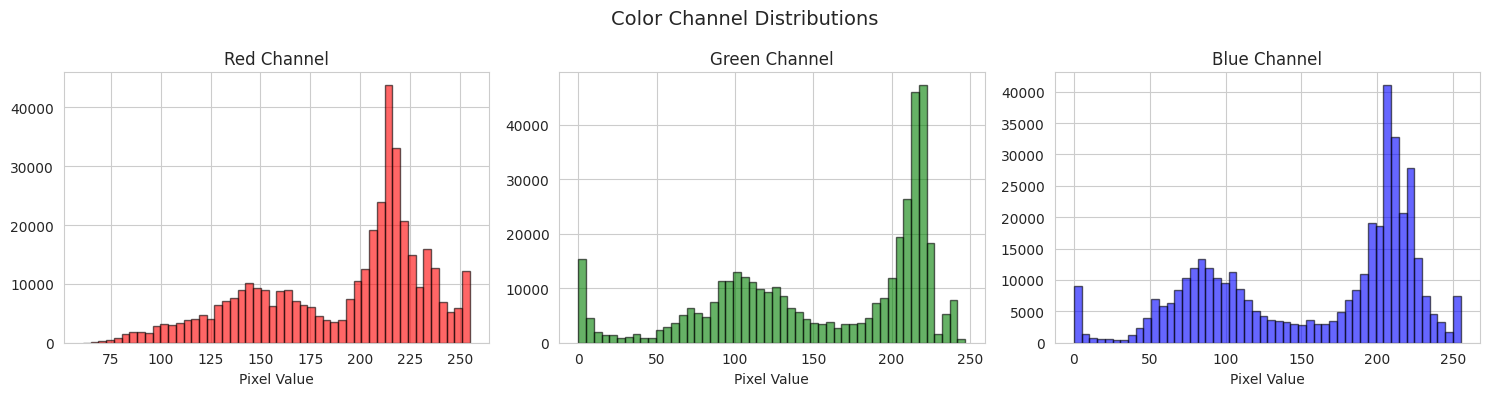

In [10]:
sample_imgs = []
# Iterate through each class name to sample images
for cls_name in class_names:
    class_dir_path = os.path.join(filepath, cls_name)
    if os.path.isdir(class_dir_path):
        # Get up to 5 image files from each class for sampling
        img_files_in_class = [f for f in os.listdir(class_dir_path) if os.path.isfile(os.path.join(class_dir_path, f))]

        for img_filename in img_files_in_class[:5]:
            full_img_path = os.path.join(class_dir_path, img_filename)
            img = cv2.imread(full_img_path) # Reads image in BGR format
            if img is not None:
                # Resize the image to match the dimensions used in image_dataset_from_directory
                img = cv2.resize(img, (img_width, img_height))
                # Convert BGR to RGB for consistent plotting with matplotlib
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                sample_imgs.append(img)

sample_imgs = np.array(sample_imgs)
print(f"Mean pixel value: {sample_imgs.mean():.2f}")
print(f"Std pixel value: {sample_imgs.std():.2f}")
print(f"Min: {sample_imgs.min()}, Max: {sample_imgs.max()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Colors order to match RGB channels after BGR to RGB conversion
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    axes[i].hist(sample_imgs[:, :, :, i].flatten(), bins=50,
                 color=color, alpha=0.6, edgecolor='black')
    axes[i].set_title(f'{color.capitalize()} Channel')
    axes[i].set_xlabel('Pixel Value')
plt.suptitle('Color Channel Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Data preprocessing & Augmentation

In [12]:
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 5


In [13]:
TRAIN_SPLIT_RATIO = 0.8
VAL_SPLIT_RATIO = 0.1
TEST_SPLIT_RATIO = 0.1

# Calculate the total split for validation and test combined (20% of total data)
total_val_test_split_ratio = VAL_SPLIT_RATIO + TEST_SPLIT_RATIO

# Create training dataset (80% of total data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=total_val_test_split_ratio,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Create a temporary dataset for validation and test (the remaining 20% of total data)
temp_val_test_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=total_val_test_split_ratio,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Split the temporary dataset into actual validation (10%) and test (10%) sets
num_temp_val_test_batches = tf.data.experimental.cardinality(temp_val_test_ds).numpy()
val_batches = num_temp_val_test_batches // 2  # Split 50/50 for val and test

val_ds = temp_val_test_ds.take(val_batches)
test_ds = temp_val_test_ds.skip(val_batches)

# Get class names from the training dataset
class_names = train_ds.class_names
print(f"Classes: {class_names}")

# Print dataset sizes for verification
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 2000 files belonging to 5 classes.
Using 1600 files for training.
Found 2000 files belonging to 5 classes.
Using 400 files for validation.
Classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']
Number of training batches: 50
Number of validation batches: 6
Number of test batches: 7


## Augmentation

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")

print("Augmentation layers:")
for layer in data_augmentation.layers:
    print(f"  • {layer.name}")


Augmentation layers:
  • random_flip
  • random_rotation
  • random_zoom
  • random_translation
  • random_contrast
  • random_brightness


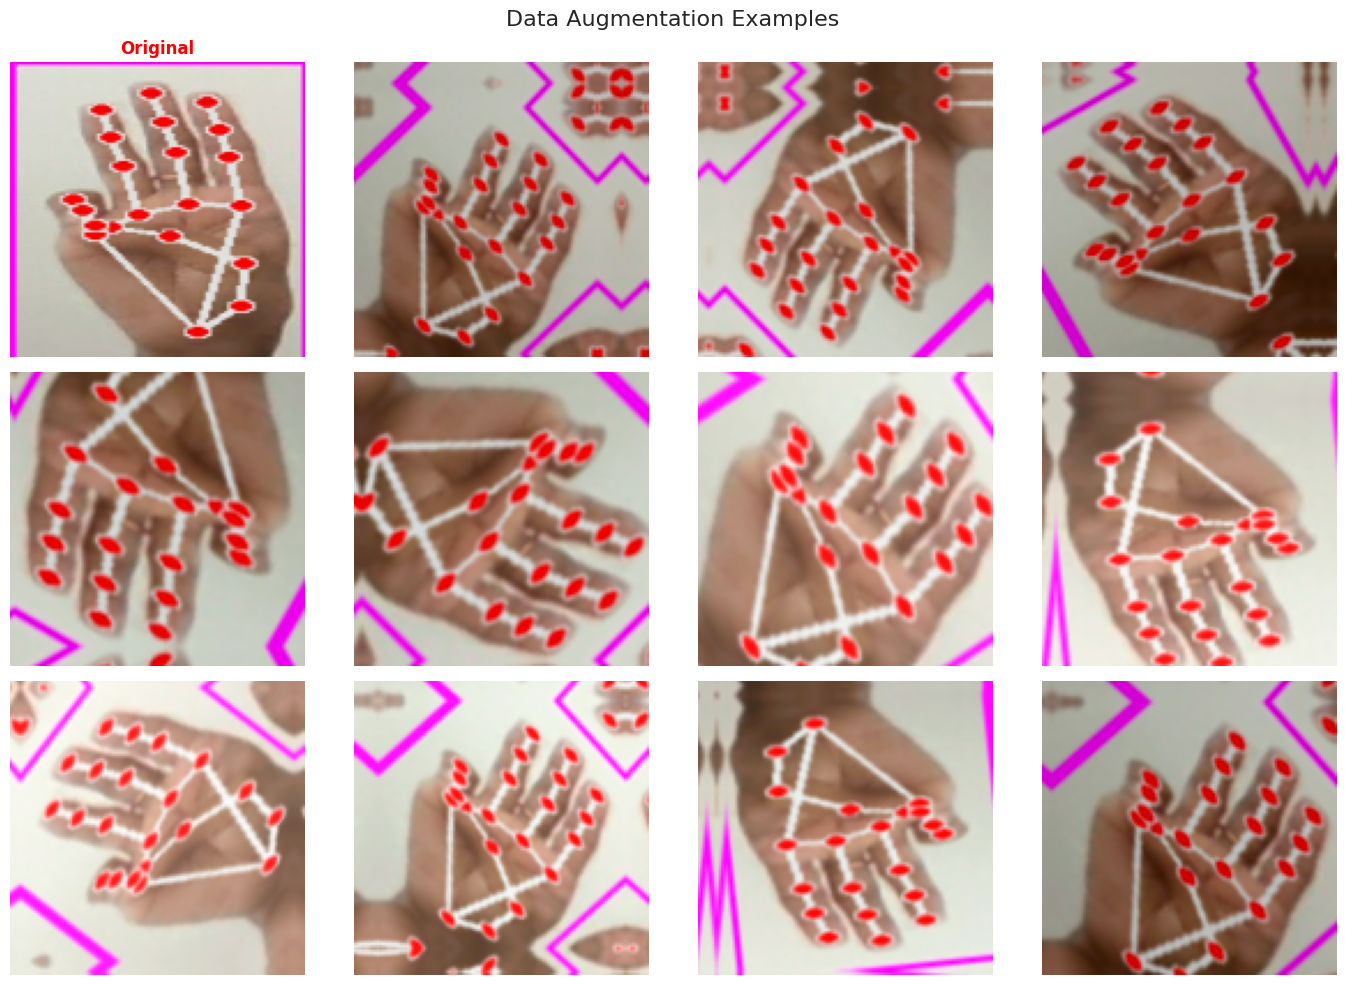

In [15]:
# visualising the augmentation
for images, labels in train_ds.take(1):
    sample_image = images[0:1]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i in range(3):
    for j in range(4):
        if i == 0 and j == 0:
            augmented = sample_image[0]
            axes[i, j].set_title("Original", fontweight='bold', color='red')
        else:
            augmented = data_augmentation(sample_image, training=True)[0]
        axes[i, j].imshow(augmented.numpy().astype('uint8'))
        axes[i, j].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=16)
plt.tight_layout()
plt.show()

## Normalization

  Rescale [0,1]             → range: [0.00, 1.00]
  Rescale [-1,1]            → range: [-1.00, 1.00]
  ImageNet Mean/Std         → range: [-2.04, 2.64]
  Per-image                 → range: [-2.91, 1.56]


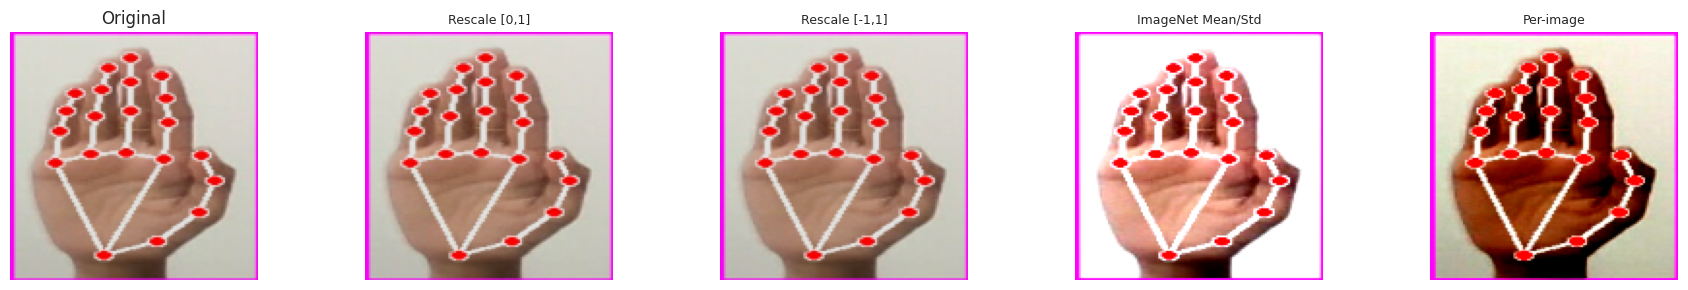

In [16]:
normalization_methods = {
    'Rescale [0,1]': lambda x: x / 255.0,
    'Rescale [-1,1]': lambda x: (x / 127.5) - 1.0,
    'ImageNet Mean/Std': lambda x: (x/255.0 - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225],
    'Per-image': lambda x: (x - x.mean()) / (x.std() + 1e-7)
}

# Get a sample image from the training dataset
for images, _ in train_ds.take(1):
    sample = images[0].numpy().astype(np.float32)
    break # Only need one image

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(sample.astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i, (name, func) in enumerate(normalization_methods.items()):
    normalized = func(sample.copy())
    # Clip for display
    display_img = np.clip(normalized, 0, 1) if 'Rescale [0,1]' in name else \
                  np.clip((normalized + 1) / 2, 0, 1) if '[-1,1]' in name else \
                  np.clip(normalized * 0.5 + 0.5, 0, 1)
    axes[i+1].imshow(display_img)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].axis('off')
    print(f"  {name:25s} → range: [{normalized.min():.2f}, {normalized.max():.2f}]")

plt.tight_layout()
plt.show()

# Model building - CNN

In [18]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build a custom CNN from scratch"""

    model = keras.Sequential([
        # Input & Augmentation
        layers.Input(shape=input_shape),
        data_augmentation,

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),

        # Classifier
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 685,349 (2.61 MB)

 Trainable params: 683,429 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Callbacks

In [19]:

cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2,
        patience=5, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print("Callbacks configured:")
print("  • EarlyStopping (patience=10)")
print("  • ReduceLROnPlateau (factor=0.2)")
print("  • ModelCheckpoint (best val_accuracy)")

Callbacks configured:
  • EarlyStopping (patience=10)
  • ReduceLROnPlateau (factor=0.2)
  • ModelCheckpoint (best val_accuracy)


## model training

In [20]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2542 - loss: 2.2296
Epoch 1: val_accuracy improved from None to 0.17708, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.3069 - loss: 1.9634 - val_accuracy: 0.1771 - val_loss: 92.2268 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4859 - loss: 1.3740
Epoch 2: val_accuracy did not improve from 0.17708
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.4919 - loss: 1.3372 - val_accuracy: 0.1771 - val_loss: 41.9306 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5249 - loss: 1.1709
Epoch 3: val_accuracy did not improve from 0.17708
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.5369 - loss: 1.1679 - val_accuracy: 0.1771 - val_loss: 10.7020 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5909 - loss: 

## Training history

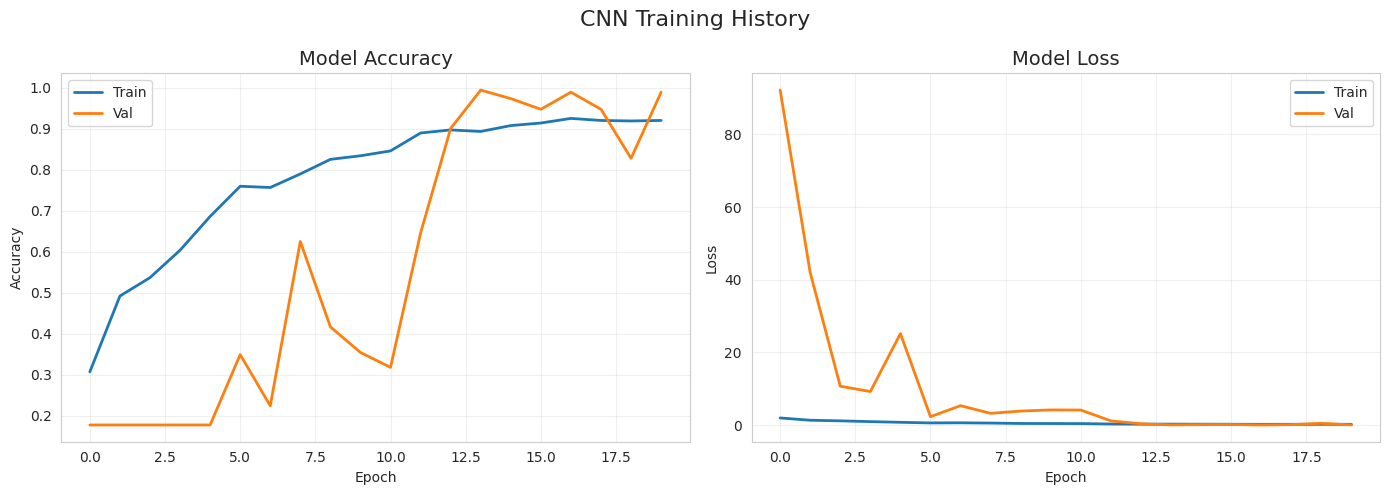

Best Val Accuracy: 0.9948
Best Val Loss: 0.0316


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(cnn_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Val', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(cnn_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Val', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training History', fontsize=16)
plt.tight_layout()
plt.show()

print(f"Best Val Accuracy: {max(cnn_history.history['val_accuracy']):.4f}")
print(f"Best Val Loss: {min(cnn_history.history['val_loss']):.4f}")

# Transfer Learning

## Building Transfer Learning Model

In [22]:
def build_transfer_model(base_model_class, base_name, input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         num_classes=NUM_CLASSES, fine_tune_layers=20):
    """Build a transfer learning model"""

    # Load base model (pretrained on ImageNet)
    base_model = base_model_class(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze base model
    base_model.trainable = False

    # Build full model
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Preprocessing for specific architecture
    if 'MobileNet' in base_name:
        x = mobilenet_preprocess(x)
    elif 'ResNet' in base_name:
        x = resnet_preprocess(x)
    elif 'Efficient' in base_name:
        x = efficientnet_preprocess(x)
    else:
        x = x / 255.0

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f'TL_{base_name}')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

# Define architectures to try
architectures = {
    'MobileNetV2': MobileNetV2,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50,
}

tl_models = {}
tl_histories = {}

## Training model

In [23]:
for arch_name, arch_class in architectures.items():
    print(f"\n{'='*50}")
    print(f"Training: {arch_name}")
    print(f"{'='*50}")

    model, base_model = build_transfer_model(
        arch_class, arch_name,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=NUM_CLASSES
    )

    print(f"Total params: {model.count_params():,}")
    print(f"Trainable params: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

    tl_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                     patience=4, min_lr=1e-7, verbose=0),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=tl_callbacks,
        verbose=1
    )

    tl_models[arch_name] = {'model': model, 'base_model': base_model}
    tl_histories[arch_name] = history

    val_acc = max(history.history['val_accuracy'])
    print(f"\n{arch_name} Best Val Accuracy: {val_acc:.4f}")


Training: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 2,624,581
Trainable params: 364,037
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.6875 - loss: 0.8473 - val_accuracy: 0.9167 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8856 - loss: 0.3143 - val_accuracy: 0.9948 - val_loss: 0.0472 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9106 - loss: 0.2679 - val_accuracy: 1.0000 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9144 - loss: 0.2347 - val_accuracy: 1.0000 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9325 - loss: 0.1804 - val_accuracy: 1.0000 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9413 - loss: 0.1873 - val_accuracy: 1.0000 - val_loss: 0.

## Fine tuning

In [24]:
# Pick best model for fine-tuning
best_arch = max(tl_histories.keys(),
                key=lambda k: max(tl_histories[k].history['val_accuracy']))
print(f"Fine-tuning best model: {best_arch}")

best_model = tl_models[best_arch]['model']
best_base = tl_models[best_arch]['base_model']

# Unfreeze top layers
best_base.trainable = True
fine_tune_at = len(best_base.layers) - 20

for layer in best_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers: {len(best_base.layers)}")
print(f"Unfrozen layers: {len(best_base.layers) - fine_tune_at}")
print(f"Trainable params: {sum([tf.keras.backend.count_params(w) for w in best_model.trainable_weights]):,}")

# Recompile with lower learning rate
best_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=0),
]

print("\nStarting fine-tuning...")
ft_history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=fine_tune_callbacks,
    verbose=1
)

print(f"\nFine-tuned Val Accuracy: {max(ft_history.history['val_accuracy']):.4f}")


Fine-tuning best model: MobileNetV2
Total layers: 154
Unfrozen layers: 20
Trainable params: 1,570,117

Starting fine-tuning...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.8475 - loss: 0.4632 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8662 - loss: 0.3759 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8869 - loss: 0.2989 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9025 - loss: 0.2754 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9137 - loss: 0.2406 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9156 - loss: 0.2577 - val_accuracy: 1.0000 - val_loss: 0.0023

Fine-tuned Val Accuracy: 1.0000


## Comparing model

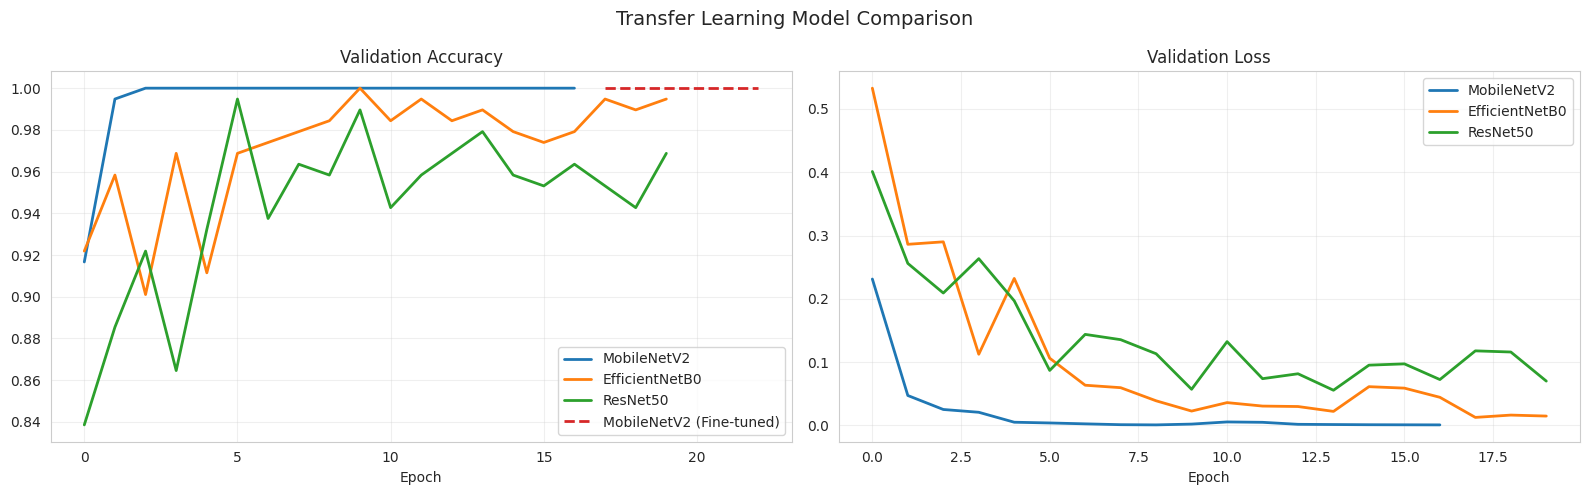


📊 Final Results:
Model                     Best Val Acc  Best Val Loss
───────────────────────────────────────────────────────
MobileNetV2                     1.0000         0.0007
EfficientNetB0                  1.0000         0.0125
ResNet50                        0.9948         0.0555
MobileNetV2 (FT)                1.0000         0.0012


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for arch_name, history in tl_histories.items():
    axes[0].plot(history.history['val_accuracy'], label=arch_name, linewidth=2)
    axes[1].plot(history.history['val_loss'], label=arch_name, linewidth=2)

# Add fine-tuning history
ft_start = len(tl_histories[best_arch].history['val_accuracy'])
axes[0].plot(range(ft_start, ft_start + len(ft_history.history['val_accuracy'])),
             ft_history.history['val_accuracy'],
             label=f'{best_arch} (Fine-tuned)', linewidth=2, linestyle='--')

axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transfer Learning Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("\nFinal Results:")
print(f"{'Model':<25} {'Best Val Acc':>12} {'Best Val Loss':>14}")
print("─" * 55)
for arch_name, history in tl_histories.items():
    acc = max(history.history['val_accuracy'])
    loss = min(history.history['val_loss'])
    print(f"{arch_name:<25} {acc:>12.4f} {loss:>14.4f}")
ft_acc = max(ft_history.history['val_accuracy'])
ft_loss = min(ft_history.history['val_loss'])
print(f"{best_arch + ' (FT)':<25} {ft_acc:>12.4f} {ft_loss:>14.4f}")

# Model Evaluation

In [26]:
# Use the fine-tuned model
eval_model = best_model


## Test Set Evaluation

In [27]:
test_loss, test_acc = eval_model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 1.0000 - loss: 0.0019

Test Accuracy: 1.0000
Test Loss: 0.0019


## Predictions & Classification Report

In [28]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = eval_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       Musti       1.00      1.00      1.00        27
      Pataka       1.00      1.00      1.00        41
     Sikhara       1.00      1.00      1.00        43
  Simhamukha       1.00      1.00      1.00        46
     Trisula       1.00      1.00      1.00        51

    accuracy                           1.00       208
   macro avg       1.00      1.00      1.00       208
weighted avg       1.00      1.00      1.00       208



## Confusion matrix

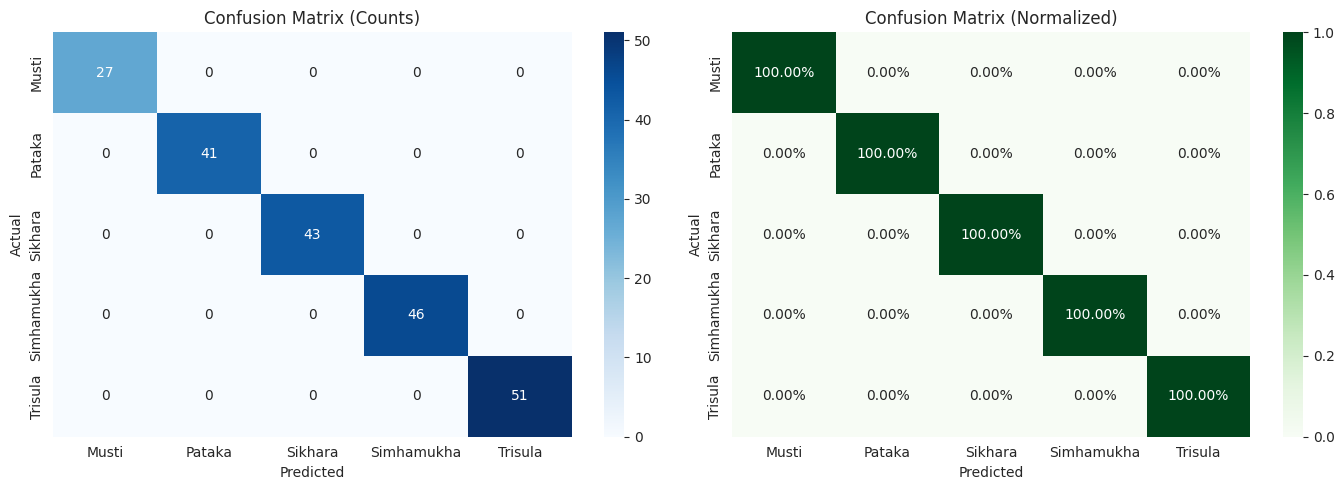

In [29]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Misclassified Images

In [30]:
misclassified_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")

if len(misclassified_idx) > 0:
    n_show = min(12, len(misclassified_idx))
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    # Get test images
    test_images = []
    test_labels = []
    for images, labels in test_ds:
        test_images.extend(images.numpy())
        test_labels.extend(np.argmax(labels.numpy(), axis=1))
    test_images = np.array(test_images)

    for i in range(n_show):
        idx = misclassified_idx[i]
        axes[i].imshow(test_images[idx].astype('uint8'))
        axes[i].set_title(
            f"True: {class_names[y_true[idx]]}\n"
            f"Pred: {class_names[y_pred[idx]]}\n"
            f"Conf: {y_prob[idx][y_pred[idx]]:.1%}",
            color='red', fontsize=9
        )
        axes[i].axis('off')

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Misclassified Examples', fontsize=16)
    plt.tight_layout()
    plt.show()

Total misclassified: 0 / 208


## Prediction Confidence

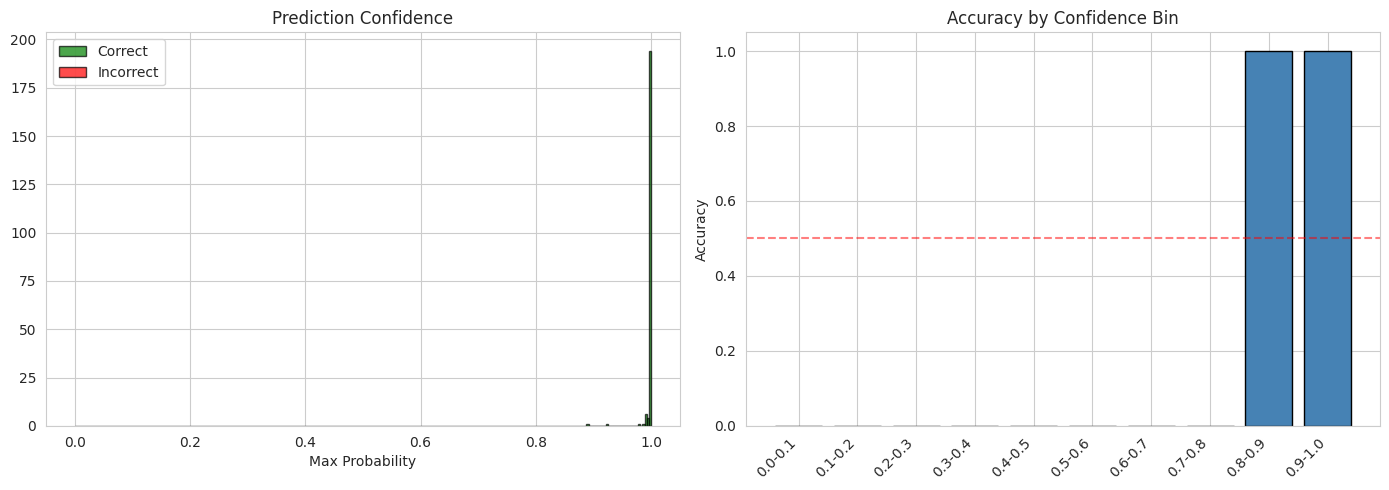

In [31]:
max_probs = np.max(y_prob, axis=1)
correct_mask = y_true == y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.7,
             label='Correct', color='green', edgecolor='black')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.7,
             label='Incorrect', color='red', edgecolor='black')
axes[0].set_title('Prediction Confidence')
axes[0].set_xlabel('Max Probability')
axes[0].legend()

# Confidence vs Accuracy
bins = np.linspace(0, 1, 11)
bin_acc = []
for i in range(len(bins)-1):
    mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct_mask[mask].mean())
    else:
        bin_acc.append(0)

axes[1].bar(range(len(bin_acc)), bin_acc, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(len(bin_acc)))
axes[1].set_xticklabels([f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)],
                         rotation=45, ha='right')
axes[1].set_title('Accuracy by Confidence Bin')
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Save Model & Artifacts

In [32]:
os.makedirs('cv_model_artifacts', exist_ok=True)

In [34]:
import pickle
from pathlib import Path

import numpy as np

model_artifact = {
    "model_json": eval_model.to_json(),
    "weights": eval_model.get_weights(),
    "class_names": class_names,
}
artifact_path = Path("cv_model_artifacts") / "mudra_classifier.pkl"
with artifact_path.open("wb") as artifact_file:
    pickle.dump(model_artifact, artifact_file, protocol=pickle.HIGHEST_PROTOCOL)

with artifact_path.open("rb") as artifact_file:
    loaded_artifact = pickle.load(artifact_file)

restored_model = tf.keras.models.model_from_json(loaded_artifact["model_json"])
restored_model.set_weights(loaded_artifact["weights"])
sample_images, _ = next(iter(test_ds))
np.testing.assert_allclose(
    restored_model.predict(sample_images, verbose=0),
    eval_model.predict(sample_images, verbose=0),
    rtol=1e-5,
    atol=1e-6,
)
print(f"Saved and verified model artifact: {artifact_path}")
print(f"Classes: {loaded_artifact['class_names']}")

Saved and verified model artifact: cv_model_artifacts/mudra_classifier.pkl
Classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']


# Streamlit deploy

In [36]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>